In [1]:
!pip install git+https://github.com/navasmontilla/HepGPU.git
!pip install zarr
!pip install pyevtk

  Cloning https://github.com/navasmontilla/HepGPU.git to /tmp/pip-req-build-p3e70c7o
  Running command git clone --filter=blob:none --quiet https://github.com/navasmontilla/HepGPU.git /tmp/pip-req-build-p3e70c7o
  Resolved https://github.com/navasmontilla/HepGPU.git to commit 65da6e73eef61f7869cfc0353a1c94fc6e763a24
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for HepGPU: filename=hepgpu-0.1.0-py3-none-any.whl size=13051 sha256=12c56426a4d2b1de8639536e815684e11e183a0599127f3b3a7d5ff789a36ba8
  Stored in directory: /tmp/pip-ephem-wheel-cache-7oh2lmc7/wheels/98/15/14/70b773247165c92dbe157a4fcb3d97b9cc207f4d939a73873e
Successfully built HepGPU
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.0 MB/s eta 0:00:00


In [3]:
import numpy as np
from HepGPU.core import run
from HepGPU.zarr_utils import export_zarr_to_vtk,export_zarr_to_png
import sys
import os


# ==========================================
# Grid del test (solo para definir máscaras)
# ==========================================

nx, ny, nz = 21, 3, 3
Lx = Ly = Lz = 1.0

x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
z = np.linspace(0, Lz, nz)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")


# ==========================================
# Máscaras)
# ==========================================


mask_inflow = (X <= 0.1) # True dentro del cilindro


# ==========================================
# Ejecutar simulación
# ==========================================

if __name__ == "__main__":
    run(
        use_gpu=False,

        Lx=Lx,
        Ly=Ly,
        Lz=Lz,

        nx=nx,
        ny=ny,
        nz=nz,

        tf=50 ,
        td=1,

        params={
            "a1": 1.0,       # virus natural decay
            "C1": 1.0,       # virus carrying capacity
            "epsilon": 0.05, # Allee effect parameter
            "kappa": 0.01,   # Allee effect parameter

            "a5": 0.055,     # T cell effectiveness

            "a2h": 2.0,      # Th inflow regulation
            "Cth": 8.0,      # Th carrying capacity
            "a6h": 0.2,      # Th decay rate

            "a2c": 2.0,      # Tc inflow regulation
            "Ctc": 15.0,     # Tc carrying capacity
            "a6c": 0.2,      # Tc decay rate

            "a3": 0.8,       # cytokine production
            "a_nd": 0.6,      # cytokine degradation

            "dTc": 0.5,
            "d1": 0.6,
            "dTh": 0.9,
            "d3": 0.5
        },

        mask_inflow=mask_inflow,

        CI_values=(0.1, 0.0, 0.0, 0.0),

        out_name = "output1D.zarr"
    )

    print("Test completado")

Grid: 21x3x3, dt=4.16667e-04, nt=119999, device=CPU
Guardando cada 2399 pasos (≈1 s simulados)
Integral de xi = 0.9999999999999997
27
Simulation time: 33.378 seconds
Datos guardados en: output1D.zarr
Test completado


In [4]:
export_zarr_to_vtk(
    zarr_file="output1D.zarr",
    output_dir="results/vtk"
)

export_zarr_to_png(
    zarr_file="output1D.zarr",
    output_dir="results/graficas"
)

Exportando 51 pasos de tiempo a .vti ...
 Guardado: results/vtk/variables_0000.vti
 Guardado: results/vtk/variables_0001.vti
 Guardado: results/vtk/variables_0002.vti
 Guardado: results/vtk/variables_0003.vti
 Guardado: results/vtk/variables_0004.vti
 Guardado: results/vtk/variables_0005.vti
 Guardado: results/vtk/variables_0006.vti
 Guardado: results/vtk/variables_0007.vti
 Guardado: results/vtk/variables_0008.vti
 Guardado: results/vtk/variables_0009.vti
 Guardado: results/vtk/variables_0010.vti
 Guardado: results/vtk/variables_0011.vti
 Guardado: results/vtk/variables_0012.vti
 Guardado: results/vtk/variables_0013.vti
 Guardado: results/vtk/variables_0014.vti
 Guardado: results/vtk/variables_0015.vti
 Guardado: results/vtk/variables_0016.vti
 Guardado: results/vtk/variables_0017.vti
 Guardado: results/vtk/variables_0018.vti
 Guardado: results/vtk/variables_0019.vti
 Guardado: results/vtk/variables_0020.vti
 Guardado: results/vtk/variables_0021.vti
 Guardado: results/vtk/variables_00

['results/graficas/frames/frame_0000.png',
 'results/graficas/frames/frame_0001.png',
 'results/graficas/frames/frame_0002.png',
 'results/graficas/frames/frame_0003.png',
 'results/graficas/frames/frame_0004.png',
 'results/graficas/frames/frame_0005.png',
 'results/graficas/frames/frame_0006.png',
 'results/graficas/frames/frame_0007.png',
 'results/graficas/frames/frame_0008.png',
 'results/graficas/frames/frame_0009.png',
 'results/graficas/frames/frame_0010.png',
 'results/graficas/frames/frame_0011.png',
 'results/graficas/frames/frame_0012.png',
 'results/graficas/frames/frame_0013.png',
 'results/graficas/frames/frame_0014.png',
 'results/graficas/frames/frame_0015.png',
 'results/graficas/frames/frame_0016.png',
 'results/graficas/frames/frame_0017.png',
 'results/graficas/frames/frame_0018.png',
 'results/graficas/frames/frame_0019.png',
 'results/graficas/frames/frame_0020.png',
 'results/graficas/frames/frame_0021.png',
 'results/graficas/frames/frame_0022.png',
 'results/g

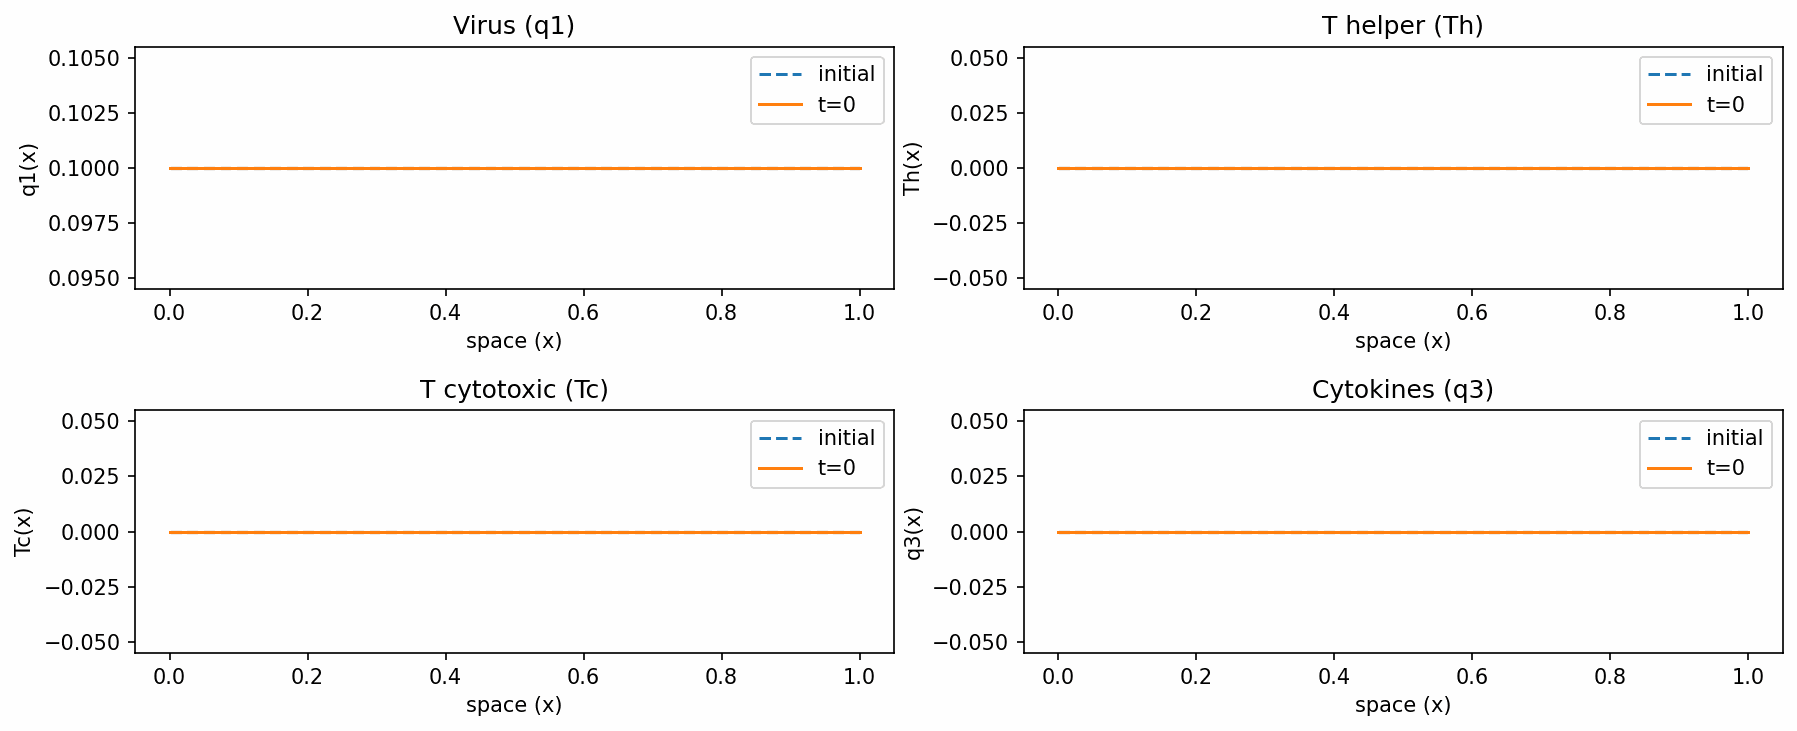

In [5]:
from IPython.display import Image, display

display(Image(filename='results/graficas/animation.gif'))